# Beamline Simulation Tutorial: Scripting with `shadow4`

*Bay Area Light Source Joint User Meeting, 2026*

**Contact:**
- Wei "Francis" He — francisho@lbl.gov
- Dr. Antoine Islegen-Wojdyla — awojdyla@lbl.gov

**Acknowledgements:**

Beamline parameters are taken from the ALS-U COSMIC-U (7.0.1) optical design.

---

## This Notebook: Looping Source, Auto-Tuning (LSAT)

This beamline is composed of a source, then a plane mirror followed by a variable-line-spacing (VLS) plane grating — a **plane-grating monochromator**, PGM. The Oasys export works at one photon energy, 1000 eV. We take it apart as in Part 1, then loop the source energy with helpers tuning source size and PGM placements accordingly.

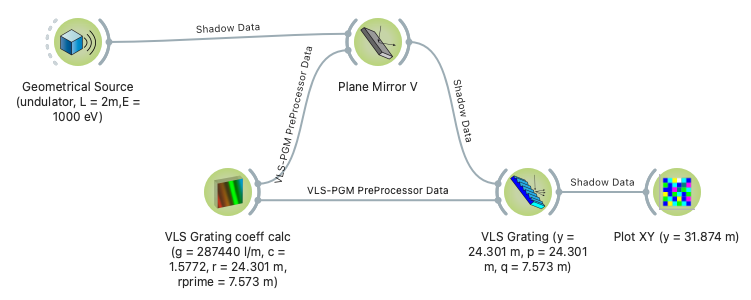

Source → plane mirror → VLS grating, 287 440 lines/m → screen at 31.874 m. The mirror deflects the beam up onto the grating, and the grating deflects it back down, parallel to where it came in.

The *VLS Grating coeff calc* widget feeds both optics: from the grating's line density, its $c_{ff}$ and the distances $r$ and $r'$, it computes the ruling and, for the source energy, the angles and positions of the mirror and the grating.

### Contents

- **0. Setup** — packages and imports.
- **1. The script from Oasys** — the export, unchanged, and what is new with two optics.
- **2. Retrace and plot** — `retrace` and `histo2` are Part 1's; nothing new here.
- **3. Beamline components** — the source; the PGM, with the angle solve that places its two optics; rebuilt and checked ray for ray against the paste.
- **4. The energy axis** — what the export does when only the energy changes; the angle solve and the source size as functions of energy; a beamline function that takes the energy as its argument, and a loop over photon energy from 600 to 2500 eV.

### Resources

- shadow4 source code and examples: [github.com/oasys-kit/shadow4](https://github.com/oasys-kit/shadow4)
- Oasys: [github.com/oasys-kit](https://github.com/oasys-kit)

## 0. Setup

Same requirements as Part 1, plus `scipy` for the angle solve in Section 3.

```bash
pip install shadow4 scipy
```


In [1]:
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt

for pkg in ["shadow4", "syned", "srxraylib", "scipy", "numpy", "matplotlib"]:
    print(f"{pkg:11s} {version(pkg)}")

shadow4     0.1.88
syned       1.0.57
srxraylib   1.0.68
scipy       1.18.0
numpy       2.5.2
matplotlib  3.11.1


## 1. The Script from Oasys

Output of the *Python Script* widget attached to the _Plot XY_ in the canvas above, unchanged.


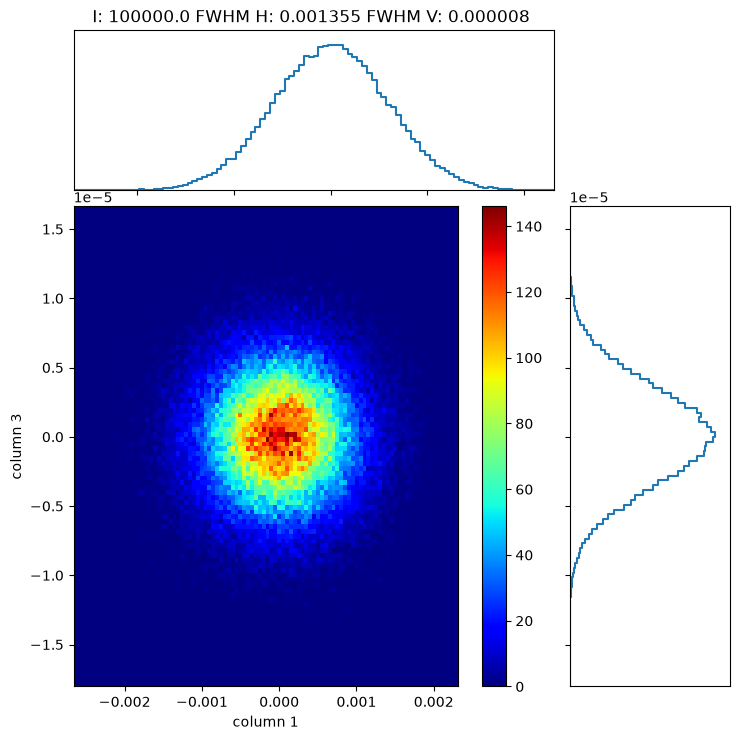

(<Figure size 800x800 with 4 Axes>,
 <Axes: xlabel='column 1', ylabel='column 3'>,
 <Axes: title={'center': 'I: 100000.0 FWHM H: 0.001355 FWHM V: 0.000008 '}>,
 <Axes: >)

In [2]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
    light_source.set_spatial_type_gaussian(sigma_h=1.65e-05,sigma_v=1.84e-05)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.86e-05,sigdiz=1.83e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155)
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='Plane Mirror V', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.09, y_top=0.09)
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating
    optical_element = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
        boundary_shape=None, f_ruling=1, order=-1,
        ruling=287440.0, ruling_coeff_linear=142771.836, 
        ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
        ruling_coeff_quartic=0.0,
        )
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)
    movements = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
    beamline_element = S4PlaneGratingElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()
beam.retrace(0.000000)

ticket = beam.histo2(1, 3, nbins_h=100, nbins_v=100, xrange=[np.float64(-0.0026856121506562787), np.float64(0.0023337723361302127)], yrange=[np.float64(-1.8206238967370853e-05), np.float64(1.680665247697966e-05)], nolost=1, ref=23)

title = "I: %.1f " % ticket['intensity']
if ticket['fwhm_h'] is not None: title += "FWHM H: %f " % ticket['fwhm_h']
if ticket['fwhm_v'] is not None: title += "FWHM V: %f " % ticket['fwhm_v']

plot_image_with_histograms(ticket['histogram'], ticket['bin_h_center'], ticket['bin_v_center'],
    title=title, xtitle="column 1", ytitle="column 3",
    cmap='jet', add_colorbar=True, figsize=(8, 8), histo_path_flag=1, show=1)


### What is new

There are two optics rather than one, and the beam returned by the mirror's `trace_beam()` is the `input_beam` of the grating block.

The two `ElementCoordinates` lines hold everything that sets up the monochromator:

| | Pre-mirror (plane) | VLS grating |
|---|---|---|
| optic | `S4PlaneMirror` | `S4PlaneGrating` |
| `p` | source → mirror | second half of the mirror–grating gap |
| `q` | first half of the mirror–grating gap | grating → focus |
| `angle_radial_out` | equal to `angle_radial` | different: $\beta$ out, $\alpha$ in |

<br>

> __Notes:__
> - **`angle_radial_out` ≠ `angle_radial` on the grating;** rather, they satisfy the grating equation $\sin\alpha - \sin\beta = \lambda g_0$ -- as we will discuss later.
> - **These angles and distances hold for 1000 eV only.** The *VLS Grating coeff calc* widget solved for them once, at the source energy, and the export froze them as numbers. At any other energy the grating angles, the mirror angle and both distances have to be recalculated — so to loop over energy, the script needs a helper that does what the widget does -- Section 3.2 writes that helper, and Section 4.3 wires it into the beamline.



## 2. Retrace and Plot

`retrace` and `histo2` work exactly as in Part 1 -- nothing new here. 

## 3. Beamline Components

The same script, one block per cell. The export reuses the names `optical_element` and `coordinates` for both optics; here each gets its own name, so both stay around to inspect. Section 3.3 checks the rebuilt beam against the pasted one.

In [3]:
beam_paste = beam.duplicate()   # keep the pasted script's result for the comparison in 3.3

### 3.1 Source

The export's source block, unchanged from Part 1: a Gaussian undulator source at 1000 eV, 100 000 rays, seed 12. Section 4.2 turns its four numbers into functions of the photon energy.


In [4]:
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical

light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
light_source.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
light_source.set_energy_distribution_singleline(1000, unit='eV')
light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
beam = light_source.get_beam()

### 3.2 PGM

Our mono is made of a VLS grating and its pre-mirror. The grating's angles decide how the mirror is tilted and where it sits.

In [5]:
from syned.beamline.shape import Rectangle
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror

# --- the pre-mirror: a plane needs no surface parameters, only an aperture
mirror = S4PlaneMirror(name='Plane Mirror V',
    boundary_shape=Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155),
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )

from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating

# --- the grating: flat as well, but ruled
grating = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
    boundary_shape=None, f_ruling=1, order=-1,
    ruling=287440.0, ruling_coeff_linear=142771.836,
    ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
    ruling_coeff_quartic=0.0,
    )

`S4PlaneMirror` takes only an aperture — 16 mm × 310 mm, written straight into the constructor — and the reflectivity switches, off as in Part 1.

`S4PlaneGrating` is flat too, but ruled. With `f_ruling=1` its line density varies along its length; with $w$ the position along the grating from its centre,

$$g(w) = g_0 + g_1 w + g_2 w^2 + g_3 w^3 .$$

| | argument | value | what it does |
|---|---|---|---|
| $g_0$ [l/m] | `ruling` | 287 440 | sets the dispersion |
| $g_1$ [l/m²] | `ruling_coeff_linear` | 142 771.836 | focuses: puts the image at $r'$ |

$g_2$ and $g_3$ correct higher-order aberrations; the appendix says where all four come from. The coefficients are the ruling of a real grating, so they never change. `order=-1` is the first inside order in shadow4's sign convention.

#### Placement and orientation

`ElementCoordinates` carries the same five numbers as in Part 1, now for two optics:

- **`p`, `q`** — the mirror sits `p` = 24.123903 m from the source, and its `q` plus the grating's `p` make up the 0.177379 m between them. The grating's `q` = 7.573 m reaches the screen.
- **`angle_radial`, `angle_radial_out`** — equal on the mirror, different on the grating ($\alpha$ in, $\beta$ out).
- **`angle_azimuthal`** — 0 on the mirror, which deflects the beam vertically upward, and π on the grating, which sends it back down. The two deflections cancel, so the beam leaves the monochromator parallel to the one that entered.

At 1000 eV we can take all five straight from the export — the widget has already solved them. The next cell does exactly that; everything after it is about where those numbers come from.


In [6]:
from syned.beamline.element_coordinates import ElementCoordinates

# The export's numbers, at 1000 eV. pgm_solve() reproduces them below.
# ElementCoordinates hands its values back through methods: p(), angle_radial().
mirror_coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)
grating_coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)

As mentioned earlier, at other energies `mirror_coordinates` and `grating_coordinates` need to change accordingly. In Oasys that means going back to the calculator widget for every energy; in a script it means writing the calculator once, as a function.

#### Placement dependent on energy: `pgm_solve()`

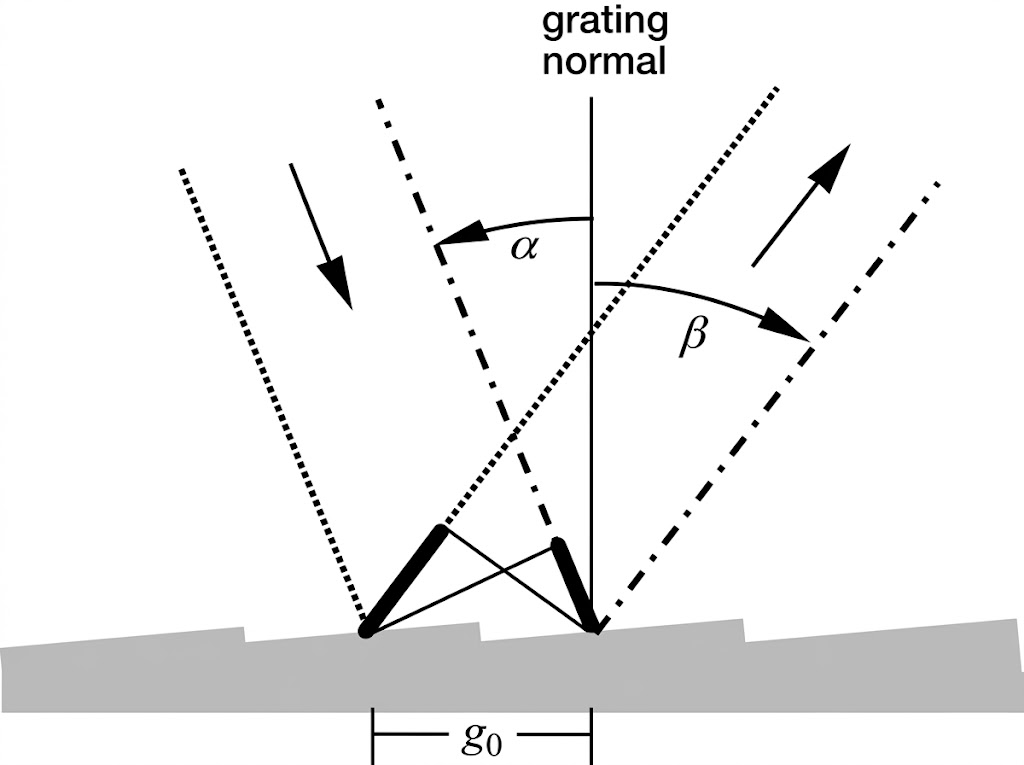

*$\alpha$ (in) and $\beta$ (out) are measured from the grating normal; the bracket marks one groove period, $1/g_0$. The two thick segments are the path difference between neighbouring grooves, which is what the grating equation counts.*

__Variables:__
- Fixed: the ruling $g_0$, $g_1$ and the layout — $r$ = 24.301 m source to grating, $r'$ = 7.573 m grating to screen.
- Undetermined: `angle_radial` = $\alpha$ and `angle_radial_out` = $\beta$, both measured from the grating's normal, as shown in the figure above. They depend on the beam wavelength $\lambda = hc/E$.

__Governing equations:__

$$\sin\alpha - \sin\beta = \lambda g_0 \qquad \text{(grating equation)}$$

$$\frac{\cos^2\alpha}{r} + \frac{\cos^2\beta}{r'} = \lambda g_1 \qquad \text{(focus on the screen)}$$

Two equations, two unknowns: `pgm_solve()` below returns $\alpha$ and $\beta$ at any photon energy.

__The c-factor.__ One more number is quoted with every grating, the ratio of the two angles, and with it the grating's magnification:

$$c = \frac{\cos\beta}{\cos\alpha}, \qquad M = \frac{r'}{r\,c}, \qquad \sigma_\text{image} = M\,\sigma_v .$$

`pgm_solve()` reads $c$ back from the angles it solved; the appendix says where it comes from.

Then the layout of the grating and the pre-mirror follows, with $D = \pi - \alpha - \beta$ the total deflection of the beam:

$$\theta_\text{mirror} = \frac{\alpha + \beta}{2}, \qquad L_{MG} = \frac{\Delta y}{\sin D}, \qquad d_{SM} = r - \frac{\Delta y}{\tan D}$$

where $L_{MG}$ and $d_{SM}$ are the mirror-to-grating and source-to-mirror distances respectively, and $\Delta y$ = 10 mm is the fixed vertical separation between the two optics.

> __Note:__ This is the calculation the *VLS Grating coeff calc* widget does, and the export froze one of its answers. Section 4 calls it at every energy of a scan.

In [7]:
from scipy.optimize import brentq

hc_eVm = 1.239841984e-6                      # h·c [eV·m]
g0_per_m, g1_per_m2 = 287440.0, 142771.836   # this grating's ruling [l/m], [l/m²]
r_m, r_prime_m, dy_m = 24.301, 7.573, 0.010  # source–grating, grating–screen, grating height [m]


# The five numbers above are the defaults, so a different grating is one call away;
# they are also used by the checks and hand estimates in the rest of the notebook.
def pgm_solve(energy_eV, g0_per_m=g0_per_m, g1_per_m2=g1_per_m2,
              r_m=r_m, r_prime_m=r_prime_m, dy_m=dy_m):
    # Angles and distances of the grating and its pre-mirror at one photon energy.
    wavelength_m = hc_eVm / energy_eV
    path_r_m = r_m                            # first guess for r; refined at the end of each pass
    for _ in range(4):
        # The grating equation gives β from α, which leaves the focus condition as one
        # equation in one unknown. It has a single root on [0°, 90°): brentq finds it.
        def focus_residual(a_rad):
            b_rad = np.arcsin(np.sin(a_rad) - wavelength_m * g0_per_m)
            return np.cos(a_rad)**2 / path_r_m + np.cos(b_rad)**2 / r_prime_m - wavelength_m * g1_per_m2
        alpha_rad = brentq(focus_residual, 0.0, np.radians(89.999), xtol=1e-15)
        beta_rad = np.arcsin(np.sin(alpha_rad) - wavelength_m * g0_per_m)

        D_rad = np.pi - alpha_rad - beta_rad  # total deflection, then the layout
        L_MG_m = dy_m / np.sin(D_rad)
        d_SM_m = r_m - dy_m / np.tan(D_rad)
        # r is the path the beam really travels, and the mirror moves with the angles,
        # so feed it back and solve again; it settles by the third pass.
        path_r_m = d_SM_m + L_MG_m

    return {"alpha_rad": alpha_rad, "beta_rad": beta_rad,
            "mirror_rad": (alpha_rad + beta_rad) / 2,    # the mirror's angle_radial
            "d_SM_m": d_SM_m, "L_MG_m": L_MG_m,
            # c is read back from the solved angles, never put into it: what fixes the
            # angles is the focus condition above.
            "cff": np.cos(beta_rad) / np.cos(alpha_rad)}

At 1000 eV the solve must return what the widget gave the export — and what the widget's *Ray-Tracing Output* shows: α = 88.746122°, β = 88.022024°, source–mirror 24.123903 m, mirror–grating 0.177379 m.

In [8]:
sol = pgm_solve(1000.0)

rows = [("α [deg]",             np.degrees(sol["alpha_rad"]),  np.degrees(grating_coordinates.angle_radial())),
        ("β [deg]",             np.degrees(sol["beta_rad"]),   np.degrees(grating_coordinates.angle_radial_out())),
        ("mirror angle [deg]",  np.degrees(sol["mirror_rad"]), np.degrees(mirror_coordinates.angle_radial())),
        ("d_SM [m]",            sol["d_SM_m"],                 mirror_coordinates.p()),
        ("L_MG [m]",            sol["L_MG_m"],                 mirror_coordinates.q() + grating_coordinates.p())]

print(f"{'':20s}{'pgm_solve':>16s}{'export':>16s}{'difference':>13s}")
for name, solved, exported in rows:
    print(f"{name:20s}{solved:16.9f}{exported:16.9f}{solved - exported:13.1e}")

# angles to 1e-8 rad, distances to 1e-6 m — the export's own precision
assert np.isclose(sol["alpha_rad"],  grating_coordinates.angle_radial(),     atol=1e-8)
assert np.isclose(sol["beta_rad"],   grating_coordinates.angle_radial_out(), atol=1e-8)
assert np.isclose(sol["mirror_rad"], mirror_coordinates.angle_radial(),      atol=1e-8)
assert np.isclose(sol["d_SM_m"], mirror_coordinates.p(), atol=1e-6)
assert np.isclose(sol["L_MG_m"], mirror_coordinates.q() + grating_coordinates.p(), atol=1e-6)

                           pgm_solve          export   difference
α [deg]                 88.746122509    88.746121984      5.2e-07
β [deg]                 88.022024066    88.022023996      7.0e-08
mirror angle [deg]      88.384073287    88.384072990      3.0e-07
d_SM [m]                24.123903476    24.123903000      4.8e-07
L_MG [m]                 0.177378631     0.177379000     -3.7e-07


#### The angles vs. photon energy

The solve answers at any energy. Between 600 and 1200 eV the angles change by about a degree — and the pre-mirror, which has to stay on the line between the source and the grating, travels several centimetres along the beam.


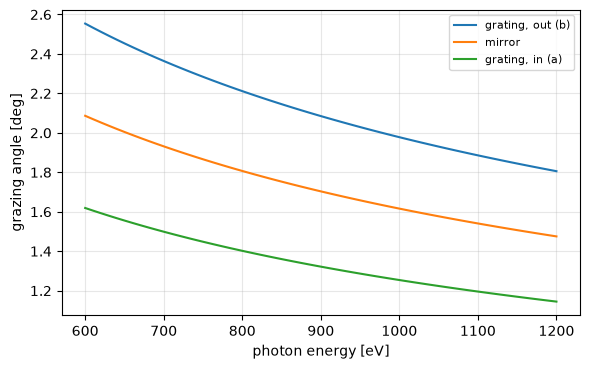

the mirror travels 57.0 mm along the beam over 600–1200 eV


In [9]:
energies_eV = np.linspace(600.0, 1200.0, 60)
sols = [pgm_solve(E_eV) for E_eV in energies_eV]

grazing_grating_in_deg  = [90 - np.degrees(s["alpha_rad"])  for s in sols]   # a = 90° − α
grazing_grating_out_deg = [90 - np.degrees(s["beta_rad"])   for s in sols]   # b = 90° − β
grazing_mirror_deg      = [90 - np.degrees(s["mirror_rad"]) for s in sols]
mirror_shift_mm = [(s["d_SM_m"] - sol["d_SM_m"]) * 1e3 for s in sols]        # relative to 1000 eV (sol, above)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(energies_eV, grazing_grating_out_deg, label="grating, out (b)")
ax.plot(energies_eV, grazing_mirror_deg, label="mirror")
ax.plot(energies_eV, grazing_grating_in_deg, label="grating, in (a)")
ax.set_xlabel("photon energy [eV]")
ax.set_ylabel("grazing angle [deg]")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"the mirror travels {max(mirror_shift_mm) - min(mirror_shift_mm):.1f} mm along the beam over 600–1200 eV")

# Away from 1000 eV there is nothing to compare against, so check the solve against its
# own two equations, with r the path the beam actually travels.
for E_eV in (600.0, 1200.0):
    s, wavelength_m = pgm_solve(E_eV), hc_eVm / E_eV
    path_r_m = s["d_SM_m"] + s["L_MG_m"]
    assert np.isclose(np.sin(s["alpha_rad"]) - np.sin(s["beta_rad"]), wavelength_m * g0_per_m, rtol=1e-9)
    assert np.isclose(np.cos(s["alpha_rad"])**2 / path_r_m + np.cos(s["beta_rad"])**2 / r_prime_m,
                      wavelength_m * g1_per_m2, rtol=1e-9)


### 3.3 Elements, trace, record

As before, each optic and its placement become an `...Element` with the beam arriving at it, and `trace_beam()` returns the beam leaving it. The mirror's output is the grating's input.

In [10]:
from shadow4.beamline.s4_beamline import S4Beamline
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement

beamline = S4Beamline()
beamline.set_light_source(light_source)

mirror_element = S4PlaneMirrorElement(optical_element=mirror, coordinates=mirror_coordinates,
                                      movements=None, input_beam=beam)
beam, mirror_footprint = mirror_element.trace_beam()
beamline.append_beamline_element(mirror_element)

grating_element = S4PlaneGratingElement(optical_element=grating, coordinates=grating_coordinates,
                                        movements=None, input_beam=beam)
beam, grating_footprint = grating_element.trace_beam()
beamline.append_beamline_element(grating_element)

print(beamline.distances_summary())

  ********  SUMMARY OF DISTANCES ********
   ** DISTANCES FOR ALL O.E. [m] **           
          OE         TYPE           p[m]           q[m]         src-oe     src-screen 
           1       MIRROR        24.1239         0.0887        24.1239        24.2126 
           2      GRATING         0.0887         7.5730        24.3013        31.8743 

   ** FOCUSING ELEMENTS **           
        OE                SHAPE      p_foc      q_foc        1/M 
         1                Plane          ?          ?          ? 

Sum of Alphas [deg]:         180.000 
Sum of Alphas Mod 180 [deg]: 0.000 
Sum of Alphas Mod 360 [deg]: 180.000 

Total deflection angle H =    -0.000000 rad =    -0.000 deg
Total deflection angle V =     0.000000 rad =     0.000 deg 



In [11]:
# The pasted `# main` ends with retrace(0.0). Tracing leaves y at ~1e-15 rather than
# exactly 0, and retrace(0) snaps it, so this line is needed for a bit-exact match.
beam.retrace(0.0)

assert np.array_equal(beam.rays, beam_paste.rays)
print("Rebuilt beam is identical to the pasted script's, ray for ray.")

Rebuilt beam is identical to the pasted script's, ray for ray.


Both optics deflect in the vertical plane, so after the grating **column 3 is lab vertical** — dispersive, and the direction the grating focuses — and **column 1 is lab horizontal**. The grating images the source, and a single real image is inverted, so **+column 3 points down**; `lab_frame()` flips it, and the rest of the notebook plots in the lab frame.

In [12]:
def rms(b, col):
    # rms of a Shadow column (numbered from 1) over good rays
    return b.rays[b.rays[:, 9] > 0, col - 1].std()

def centroid(b, col):
    return b.rays[b.rays[:, 9] > 0, col - 1].mean()

def lab_frame(b):
    # (lab horizontal, lab vertical up) positions of the good rays [m], for this beamline
    g = b.rays[:, 9] > 0
    return b.rays[g, 0], -b.rays[g, 2]

# Sanity check on the mapping: column 3 should be the vertical source demagnified by the
# grating, column 1 the horizontal source spread by its divergence over the full 31.874 m.
alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
c_factor = np.cos(beta_rad) / np.cos(alpha_rad)          # 3.2
magnification = r_prime_m / (r_m * c_factor)
assert np.isclose(rms(beam, 3), 1.84e-5 * magnification, rtol=0.01)
assert np.isclose(rms(beam, 1), np.hypot(1.65e-5, 1.86e-5 * 31.874), rtol=0.005)
print(f"c = {c_factor:.4f},  M = r'/(r c) = {magnification:.4f}")
print(f"column 3 (lab vertical) {rms(beam, 3) * 1e6:.2f} µm rms, "
      f"column 1 (lab horizontal) {rms(beam, 1) * 1e6:.0f} µm rms")

c = 1.5773,  M = r'/(r c) = 0.1976
column 3 (lab vertical) 3.64 µm rms, column 1 (lab horizontal) 593 µm rms


## 4. The Energy Axis

Every angle and distance in the export is set for 1000 eV. First we look at what the export does at another energy with its optics left alone (4.1), and then we put the energy back in: the source sizes as functions of energy (4.2), wired together with `pgm_solve()` from 3.2 into one beamline function (4.3), and looped from 600 to 2500 eV (4.4).

### 4.1 The export at another energy

`trace_frozen()` is the 3.3 cell with the photon energy as its argument and every angle and distance left at the export's values — what you get by editing only the energy in the export.

600 eV is far enough from 1000 eV for the failure to be visible on one plot, and an energy this grating reaches comfortably. Here is what the frozen export makes of it.

In [13]:
def trace_frozen(energy_eV):
    # The export at a new photon energy: only the source line changes.
    # Mirror, grating and both placements are the 1000 eV objects from Section 3.
    src = SourceGeometrical(nrays=100000, seed=12)
    src.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
    src.set_depth_distribution_off()
    src.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
    src.set_energy_distribution_singleline(energy_eV, unit='eV')
    src.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)

    # source -> mirror -> grating, handing the beam from one element to the next
    b, _ = S4PlaneMirrorElement(optical_element=mirror, coordinates=mirror_coordinates,
                                movements=None, input_beam=src.get_beam()).trace_beam()
    b, _ = S4PlaneGratingElement(optical_element=grating, coordinates=grating_coordinates,
                                 movements=None, input_beam=b).trace_beam()
    b.retrace(0.0)   # onto the screen, as # main does
    return b

# At 1000 eV nothing has changed, so this must be the paste again.
assert np.array_equal(trace_frozen(1000.0).rays, beam.rays)

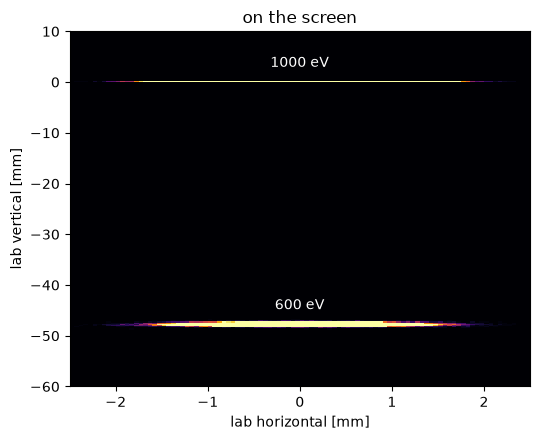

600 eV lands 47.77 mm below the axis (expected 47.77 mm)


In [14]:
b600 = trace_frozen(600.0)

h1000_m, v1000_m = lab_frame(beam)
h600_m, v600_m = lab_frame(b600)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.hist2d(np.r_[h1000_m, h600_m] * 1e3, np.r_[v1000_m, v600_m] * 1e3,
          bins=[100, 300], range=[[-2.5, 2.5], [-60, 10]], cmap="inferno", vmax=50)
ax.text(0, 3, "1000 eV", color="w", ha="center")
ax.text(0, v600_m.mean() * 1e3 + 3, "600 eV", color="w", ha="center")
ax.set_xlabel("lab horizontal [mm]")
ax.set_ylabel("lab vertical [mm]")
ax.set_title("on the screen")
plt.tight_layout()
plt.show()

# Hand estimate: at the frozen α, the grating equation sends 600 eV to a different β.
alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
wavelength_600_m = hc_eVm / 600.0
beta_600_rad = np.arcsin(np.sin(alpha_rad) - wavelength_600_m * g0_per_m)
drop_expected_m = r_prime_m * (beta_rad - beta_600_rad)

print(f"600 eV lands {-v600_m.mean() * 1e3:.2f} mm below the axis (expected {drop_expected_m * 1e3:.2f} mm)")
assert np.isclose(-v600_m.mean(), drop_expected_m, rtol=0.01)

The beam has moved, which is what a grating does with a different wavelength. It is also 209 µm tall against 3.6 µm at 1000 eV — so the focus has probably moved too?

Use `retrace` to find the focus ...

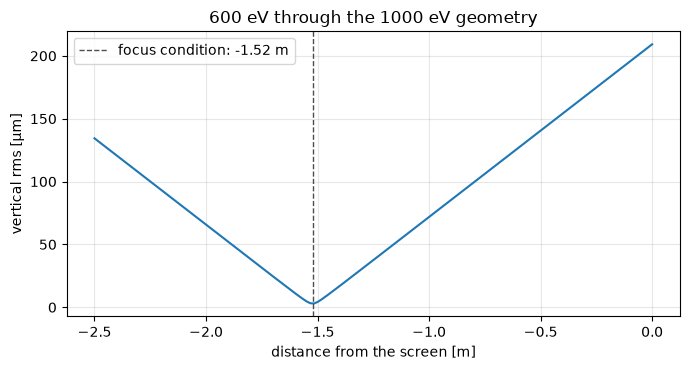

waist at -1.517 m, rms 3.0 µm (calculated focus condition: -1.521 m)


In [15]:
r_focus_m = np.cos(beta_600_rad)**2 / (wavelength_600_m * g1_per_m2 - np.cos(alpha_rad)**2 / r_m)

# Step the observation plane upstream of the screen; the rays are already traced,
# so each plane is a retrace (milliseconds), not a new trace.
dz_list_m = np.linspace(-2.5, 0.0, 151)
rms_dz_m = []
for dz_m in dz_list_m:
    b = b600.duplicate()      # retrace overwrites the rays
    b.retrace(dz_m)
    rms_dz_m.append(rms(b, 3))
rms_dz_m = np.array(rms_dz_m)
waist_m = dz_list_m[np.argmin(rms_dz_m)]   # plane of smallest vertical size

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(dz_list_m, rms_dz_m * 1e6, "-")
ax.axvline(r_focus_m - r_prime_m, color="0.3", ls="--", lw=1, label=f"focus condition: {r_focus_m - r_prime_m:.2f} m")
ax.set_xlabel("distance from the screen [m]")
ax.set_ylabel("vertical rms [µm]")
ax.set_title("600 eV through the 1000 eV geometry")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"waist at {waist_m:.3f} m, rms {rms_dz_m.min() * 1e6:.1f} µm (calculated focus condition: {r_focus_m - r_prime_m:.3f} m)")


It did move: 1.5 m upstream of the screen. And the beam there is not ruined — 3.0 µm rms, tighter than the 3.6 µm the same beamline gives at 1000 eV, because the shorter image distance demagnifies a little more.

So nothing is broken. The grating still makes a good focus at 600 eV; it simply makes it in the wrong place, 1.5 m short of the screen and 48 mm off the axis. An exit slit is a fixed hole in a fixed wall, so to put every energy through it the angles **and** the distances have to follow the energy — which is what `pgm_solve()` computes, and what the rest of Section 4 wires in.


### 4.2 `source_sizes()` — the undulator source vs. energy

The photon source is the electron beam and the single-electron undulator emission, added in quadrature:

$$\Sigma = \sqrt{\sigma_e^2 + \sigma_r^2}, \qquad \Sigma' = \sqrt{\sigma_e'^2 + \sigma_r'^2}$$

| | size | divergence | depends on photon energy |
|---|---|---|---|
| electron beam: emittance $\varepsilon$, beta function $\beta_{x,y}$ | $\sqrt{\varepsilon\,\beta}$ | $\sqrt{\varepsilon/\beta}$ | no |
| undulator emission, length $L_u$ | $\dfrac{\sqrt{2\lambda L_u}}{2\pi}$ | $\sqrt{\dfrac{\lambda}{2L_u}}$ | yes |

ALS-U: $\varepsilon$ = 71 pm in both planes, $\beta_x$ = 2.05 m, $\beta_y$ = 3.0 m. COSMIC-U's undulator: $L_u$ = 2 m.

In [16]:
def source_sizes(energy_eV):
    # rms size [m] and divergence [rad] of the photon source, horizontal and vertical
    wavelength_m = hc_eVm / energy_eV
    emittance_m, beta_x_m, beta_y_m, undulator_m = 71e-12, 2.05, 3.0, 2.0

    photon_size_m = np.sqrt(2 * wavelength_m * undulator_m) / (2 * np.pi)
    photon_div_rad = np.sqrt(wavelength_m / (2 * undulator_m))

    return {"sigma_h_m": np.hypot(np.sqrt(emittance_m * beta_x_m), photon_size_m),
            "sigma_v_m": np.hypot(np.sqrt(emittance_m * beta_y_m), photon_size_m),
            "div_h_rad": np.hypot(np.sqrt(emittance_m / beta_x_m), photon_div_rad),
            "div_v_rad": np.hypot(np.sqrt(emittance_m / beta_y_m), photon_div_rad)}

At 1000 eV it must give the four numbers the export typed in, to the digits it typed.

In [17]:
export_source = {"sigma_h_m": 1.65e-05, "sigma_v_m": 1.84e-05, "div_h_rad": 1.86e-05, "div_v_rad": 1.83e-05}

for E_eV in (600.0, 1000.0, 1200.0):
    s = source_sizes(E_eV)
    print(f"{E_eV:6.1f} eV   size h, v {s['sigma_h_m'] * 1e6:5.2f}, {s['sigma_v_m'] * 1e6:5.2f} µm   "
          f"divergence h, v {s['div_h_rad'] * 1e6:5.2f}, {s['div_v_rad'] * 1e6:5.2f} µrad")

s1000 = source_sizes(1000.0)
for key, value in export_source.items():
    assert round(s1000[key] * 1e6, 1) == round(value * 1e6, 1), key   # the export keeps three digits

 600.0 eV   size h, v 18.84, 20.55 µm   divergence h, v 23.48, 23.24 µrad
1000.0 eV   size h, v 16.47, 18.40 µm   divergence h, v 18.56, 18.27 µrad
1200.0 eV   size h, v 15.82, 17.82 µm   divergence h, v 17.12, 16.79 µrad


Both terms matter here: the electron beam sets the floor, and the undulator term — the only energy-dependent part — grows toward the low end, so both the size and the divergence change across the range.

### 4.3 `run_beamline(energy_eV)`

The export's `run_beamline()`, with the energy as its argument. Source from `source_sizes()`, both optics placed from `pgm_solve()`; the optics themselves, the apertures and the azimuths are the export's.

It comes in two halves, so each can be checked on its own:

- `trace(energy_eV, source, geometry)` — builds and traces from numbers it is given;
- `run_beamline(energy_eV)` — computes those numbers, then calls `trace`.

In [18]:
def trace(energy_eV, source, geometry, nrays=100000, seed=12, energy_spread=0.0):
    # --- source: the export's block, with the four numbers from `source`
    light_source = SourceGeometrical(nrays=nrays, seed=seed)
    light_source.set_spatial_type_gaussian(sigma_h=source["sigma_h_m"], sigma_v=source["sigma_v_m"])
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=source["div_h_rad"], sigdiz=source["div_v_rad"])
    if energy_spread:   # three lines, E and its two neighbours, for 4.4
        light_source.set_energy_distribution_severallines(
            [energy_eV * (1 - energy_spread), energy_eV, energy_eV * (1 + energy_spread)], unit='eV')
    else:
        light_source.set_energy_distribution_singleline(energy_eV, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    b = light_source.get_beam()

    # --- plane mirror (3.2): p = d_SM, q = first half of L_MG
    half_gap_m = geometry["L_MG_m"] / 2
    coords = ElementCoordinates(p=geometry["d_SM_m"], q=half_gap_m, angle_azimuthal=0,
                                angle_radial=geometry["mirror_rad"], angle_radial_out=geometry["mirror_rad"])
    b, _ = S4PlaneMirrorElement(optical_element=mirror, coordinates=coords, movements=None, input_beam=b).trace_beam()

    # --- VLS grating (3.2): p = second half of L_MG, q = r'
    coords = ElementCoordinates(p=half_gap_m, q=r_prime_m, angle_azimuthal=3.141592654,
                                angle_radial=geometry["alpha_rad"], angle_radial_out=geometry["beta_rad"])
    b, footprint = S4PlaneGratingElement(optical_element=grating, coordinates=coords, movements=None, input_beam=b).trace_beam()

    b.retrace(0.0)   # onto the screen, as # main does
    return b, footprint


def run_beamline(energy_eV, nrays=100000, seed=12, energy_spread=0.0):
    return trace(energy_eV, source_sizes(energy_eV), pgm_solve(energy_eV),
                 nrays=nrays, seed=seed, energy_spread=energy_spread)

**Check at 1000 eV, in two steps.** Given the export's own numbers, `trace()` must reproduce the paste ray for ray — that checks the wiring. `run_beamline(1000)` then differs only by the export's rounding, so its image must agree to a fraction of a percent.

In [19]:
# The export's numbers, as typed. The mirror-grating gap is written as two halves of
# 0.0886895 m in the export, so L_MG is their sum; halving it again gives them back exactly.
export_geometry = {"alpha_rad": 1.548912027, "beta_rad": 1.536274133, "mirror_rad": 1.54259308,
                   "d_SM_m": 24.123903, "L_MG_m": 2 * 0.0886895}

b_wired, _ = trace(1000.0, export_source, export_geometry)
assert np.array_equal(b_wired.rays, beam_paste.rays)
print("trace() with the export's numbers: identical to the paste, ray for ray")

b_solved, _ = run_beamline(1000.0)
for col, name in [(1, "horizontal"), (3, "vertical")]:
    print(f"{name:10s} rms  paste {rms(beam_paste, col) * 1e6:8.3f} µm   run_beamline {rms(b_solved, col) * 1e6:8.3f} µm")
    assert np.isclose(rms(b_solved, col), rms(beam_paste, col), rtol=0.005)
assert abs(centroid(b_solved, 3)) < 0.1e-6   # still on axis

trace() with the export's numbers: identical to the paste, ray for ray
horizontal rms  paste  593.276 µm   run_beamline  592.104 µm
vertical   rms  paste    3.641 µm   run_beamline    3.641 µm


**And at 600 eV**, where the frozen export missed by 48 mm:

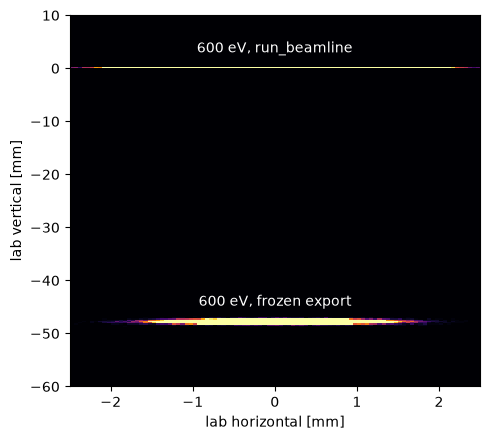

centroid -0.023 µm   rms 4.07 µm   (expected 4.06 µm)


In [20]:
b600_solved, _ = run_beamline(600.0)
h_m, v_m = lab_frame(b600_solved)

# Hand estimate of the image size: vertical source × grating magnification, both at 600 eV
s600, g600 = source_sizes(600.0), pgm_solve(600.0)
magnification_600 = r_prime_m / (r_m * g600["cff"])
expected_600_m = s600["sigma_v_m"] * magnification_600

# Frozen vs. solved, on the screen.
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.hist2d(np.r_[h600_m, h_m] * 1e3, np.r_[v600_m, v_m] * 1e3, bins=[100, 300],
          range=[[-2.5, 2.5], [-60, 10]], cmap="inferno", vmax=50)
ax.text(0, 3, "600 eV, run_beamline", color="w", ha="center")
ax.text(0, v600_m.mean() * 1e3 + 3, "600 eV, frozen export", color="w", ha="center")
ax.set_xlabel("lab horizontal [mm]")
ax.set_ylabel("lab vertical [mm]")
plt.tight_layout()
plt.show()

print(f"centroid {v_m.mean() * 1e6:+.3f} µm   rms {v_m.std() * 1e6:.2f} µm   (expected {expected_600_m * 1e6:.2f} µm)")
assert abs(v_m.mean()) < 0.1e-6
assert np.isclose(v_m.std(), expected_600_m, rtol=0.02)

### 4.4 Scan across the energy range

`run_beamline()` takes the energy, so the scan is a `for` loop: 77 energies from 600 to 2500 eV, each with its own angles, its own distances and its own source, each one trace of 100 000 rays — about half a minute for the lot.

Each trace uses a **three-line source** — $E$ and $E(1 \pm \delta)$, with $\delta$ a couple of parts in ten thousand — so that one scan answers two questions. Column 26 is every ray's photon energy, so the central line can be picked out of the beam for the widths, while all three lines together show whether the monochromator separates them.


In [21]:
# This could take a little while
import time

scan_eV = np.linspace(600, 2500, 77)    # energies to scan [eV]
probe = 1 / 6000                        # the two satellite lines sit at E(1 ± probe)
half_width_m = 30e-6                    # profile half-width, lab vertical [m]
nbins = 241


def fwhm_m(values_m, nbins=61):
    # Full width at half maximum, measured off the rays: histogram over ±4σ, then
    # interpolate the two half-maximum crossings. No Gaussian assumed. 31 bins over
    # ±4σ is a quarter-σ each: fine enough to place the crossings, coarse enough that
    # the peak bin is not set by counting noise (which biases the height high and the
    # width low — 81 bins here would read 2 % narrow).
    counts, edges = np.histogram(values_m, bins=nbins,
                                 range=(values_m.mean() - 4 * values_m.std(),
                                        values_m.mean() + 4 * values_m.std()))
    centres = (edges[:-1] + edges[1:]) / 2
    half = counts.max() / 2
    above = np.flatnonzero(counts >= half)
    lo, hi = above[0], above[-1]
    left  = np.interp(half, [counts[lo - 1], counts[lo]], [centres[lo - 1], centres[lo]])
    right = np.interp(half, [counts[hi + 1], counts[hi]], [centres[hi + 1], centres[hi]])
    return right - left


t0_s = time.time()
centroid_m, rms_v_m, rms_h_m, fwhm_v_m, dispersion_m_per_eV, profiles = [], [], [], [], [], []

for energy_eV in scan_eV:
    b, _ = run_beamline(energy_eV, energy_spread=probe)
    h_m, v_m = lab_frame(b)

    # Column 26 is each ray's photon energy, so the three lines can be told apart: the
    # central one carries the widths, the outer two measure how far apart the grating
    # puts neighbouring energies, and all three together make the profile.
    line_eV = b.get_column(26, nolost=1)
    central = np.abs(line_eV - energy_eV) < energy_eV * probe / 2
    upper, lower = line_eV > energy_eV * (1 + probe / 2), line_eV < energy_eV * (1 - probe / 2)

    centroid_m.append(v_m[central].mean())
    rms_v_m.append(v_m[central].std())
    rms_h_m.append(h_m[central].std())
    fwhm_v_m.append(fwhm_m(v_m[central]))
    dispersion_m_per_eV.append((v_m[upper].mean() - v_m[lower].mean()) / (2 * energy_eV * probe))
    profiles.append(np.histogram(v_m, bins=nbins, range=(-half_width_m, half_width_m))[0])

centroid_m, rms_v_m, rms_h_m = np.array(centroid_m), np.array(rms_v_m), np.array(rms_h_m)
fwhm_v_m, dispersion_m_per_eV = np.array(fwhm_v_m), np.array(dispersion_m_per_eV)
profiles = np.array(profiles, dtype=float)      # rows: energies, columns: position bins

print(f"{len(scan_eV)} traces in {time.time() - t0_s:.1f} s, "
      f"{central.sum()} rays on the central line of each")


77 traces in 21.6 s, 33440 rays on the central line of each


First the width of that central line, against the hand estimate of 4.3 — the vertical source of 4.2, demagnified by the grating's $M = r'/(r\,c)$ — now evaluated at every energy rather than at one.

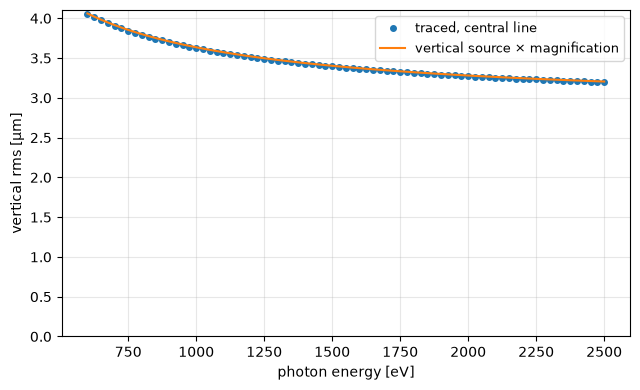

image 3.20–4.05 µm rms, centroid within 0.02 µm of the axis, magnification 0.1975–0.1976
the frozen geometry would have swept the same range from +48 mm to -52 mm off the axis


In [22]:
# Hand estimates at every energy: vertically the demagnified source, horizontally the
# source spread by its own divergence over the whole path (both as in 3.3, now vs. energy).
model_v_m, model_h_m, magnification = [], [], []
for energy_eV in scan_eV:
    s, g = source_sizes(energy_eV), pgm_solve(energy_eV)
    M = r_prime_m / (r_m * g["cff"])                 # 3.2
    path_m = g["d_SM_m"] + g["L_MG_m"] + r_prime_m
    magnification.append(M)
    model_v_m.append(s["sigma_v_m"] * M)
    model_h_m.append(np.hypot(s["sigma_h_m"], s["div_h_rad"] * path_m))
model_v_m, model_h_m = np.array(model_v_m), np.array(model_h_m)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(scan_eV, rms_v_m * 1e6, "o", ms=4, label="traced, central line")
ax.plot(scan_eV, model_v_m * 1e6, "-", lw=1.5, label="vertical source × magnification")
ax.set_xlabel("photon energy [eV]")
ax.set_ylabel("vertical rms [µm]")
ax.set_ylim(0, None)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"image {rms_v_m.min() * 1e6:.2f}–{rms_v_m.max() * 1e6:.2f} µm rms, centroid within "
      f"{abs(centroid_m).max() * 1e6:.2f} µm of the axis, "
      f"magnification {min(magnification):.4f}–{max(magnification):.4f}")

# For comparison, where the frozen geometry of 4.1 would have put the same energies:
# at the export's fixed α, each energy leaves the grating at its own β.
alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
frozen_drop_mm = r_prime_m * (beta_rad - np.arcsin(np.sin(alpha_rad) - hc_eVm / scan_eV * g0_per_m)) * 1e3
print(f"the frozen geometry would have swept the same range from {frozen_drop_mm.max():+.0f} mm "
      f"to {frozen_drop_mm.min():+.0f} mm off the axis")

assert np.all(abs(centroid_m) < 0.1e-6)             # every energy on the axis
assert np.allclose(rms_v_m, model_v_m, rtol=0.015)  # vertical: the source, demagnified
assert np.allclose(rms_h_m, model_h_m, rtol=0.01)   # horizontal: unfocused, divergence-driven

Now the other question the same scan answers. A width on its own says where the beam lands, not whether two nearby energies can be separated — that takes the other two lines.

Two numbers decide it: how far apart neighbouring energies land, and how wide each line is. The spacing is the dispersion,

$$\frac{\mathrm{d}z}{\mathrm{d}E} = r' \frac{\mathrm{d}\beta}{\mathrm{d}E} = \frac{r' g_0 \lambda}{E\cos\beta},$$

and the ratio of the two is the resolving power a matched exit slit would give,

$$R = \frac{E}{\Delta E}, \qquad \Delta E = \frac{\mathrm{FWHM}}{\mathrm{d}z/\mathrm{d}E}.$$

Both are in the rays already: the satellites' centroids measure $\mathrm{d}z/\mathrm{d}E$, and the central line's own profile measures the FWHM. So $R$ below is traced, and the formulas — dispersion, and the hand-estimate width of the first figure — are the curve it is checked against.


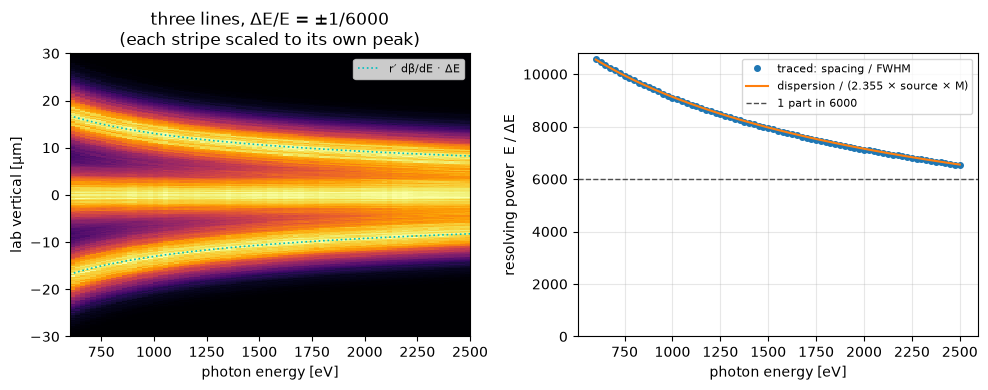

   600 eV: satellites 16.82 µm out (formula 16.82), line 9.55 µm FWHM = 2.36 × rms, R = 10565 (formula 10556)
  1550 eV: satellites 10.46 µm out (formula 10.47), line 8.00 µm FWHM = 2.37 × rms, R =  7845 (formula  7873)
  2500 eV: satellites  8.24 µm out (formula  8.24), line 7.57 µm FWHM = 2.37 × rms, R =  6527 (formula  6552)


In [23]:
# Traced, from the three lines: the satellites' spacing is the dispersion (measured in the
# loop above), the central line's FWHM is the width. The curves are the two formulas.
dispersion_model_m_per_eV = np.array([r_prime_m * g0_per_m * (hc_eVm / E_eV) / (E_eV * np.cos(pgm_solve(E_eV)["beta_rad"]))
                                      for E_eV in scan_eV])
separation_m = dispersion_m_per_eV * scan_eV * probe                                 # centre line to satellite
resolving_power = scan_eV * dispersion_m_per_eV / fwhm_v_m                           # traced
resolving_power_model = scan_eV * dispersion_model_m_per_eV / (2.3548 * model_v_m)   # both formulas

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow((profiles / profiles.max(axis=1, keepdims=True)).T,
               origin="lower", aspect="auto", interpolation="nearest", cmap="inferno",
               extent=[scan_eV[0], scan_eV[-1], -half_width_m * 1e6, half_width_m * 1e6])
for sign in (+1, -1):
    axes[0].plot(scan_eV, sign * dispersion_model_m_per_eV * scan_eV * probe * 1e6, "c:", lw=1.2,
                 label="r′ dβ/dE · ΔE" if sign == 1 else None)
axes[0].set_ylabel("lab vertical [µm]")
axes[0].set_title(f"three lines, ΔE/E = ±1/{1 / probe:.0f}\n(each stripe scaled to its own peak)")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot(scan_eV, resolving_power, "o", ms=4, label="traced: spacing / FWHM")
axes[1].plot(scan_eV, resolving_power_model, "-", lw=1.5, label="dispersion / (2.355 × source × M)")
axes[1].axhline(1 / probe, color="0.3", ls="--", lw=1, label=f"1 part in {1 / probe:.0f}")
axes[1].set_ylabel("resolving power  E / ΔE")
axes[1].set_ylim(0, None)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel("photon energy [eV]")
plt.tight_layout()
plt.show()

for k in (0, len(scan_eV) // 2, len(scan_eV) - 1):
    print(f"{scan_eV[k]:6.0f} eV: satellites {separation_m[k] * 1e6:5.2f} µm out "
          f"(formula {dispersion_model_m_per_eV[k] * scan_eV[k] * probe * 1e6:5.2f}), line "
          f"{fwhm_v_m[k] * 1e6:4.2f} µm FWHM = {fwhm_v_m[k] / rms_v_m[k]:.2f} × rms, "
          f"R = {resolving_power[k]:5.0f} (formula {resolving_power_model[k]:5.0f})")

assert np.allclose(dispersion_m_per_eV, dispersion_model_m_per_eV, rtol=0.005)  # spacing: rays vs r′ dβ/dE
assert np.allclose(resolving_power, resolving_power_model, rtol=0.01)           # traced R vs the formulas
assert np.all(resolving_power > 1 / probe)          # the satellites stay at least one FWHM out
assert resolving_power[0] > resolving_power[-1]     # the margin shrinks with energy


Both curves fall for the same reason and a different one. The width falls because the *source* shrinks with energy — the optics do not change, and the magnification is constant to a fraction of a percent. The resolving power falls because the dispersion collapses faster than the source does, so the satellites crowd in on a line that is barely narrowing.

Two things follow, and they are the rest of the story. One is the grating: a ruling with steeper angles disperses more, which is how a real beamline buys the resolving power back at the top of a scan — at the cost of covering less of it. The other is that every optic in this notebook is perfect, which no optic is — and what is left of the margin is what a real surface has to spend.

## Wrap-up

An export frozen at one photon energy, taken apart and given an energy axis: two equations for the grating angles, one formula for the source, and a `for` loop for the scan.

**Part 3** takes the second of the two threads above. It puts a refocusing mirror after this monochromator, gives it the surface a real mirror has — measured figure errors — and asks what they cost.

## Appendix — where the ruling comes from

This notebook takes the ruling $g_0 \dots g_3$ as given and solves for the angles. The *VLS Grating coeff calc* widget runs the other way, once, when the grating is designed:

| | given | solved for |
|---|---|---|
| **design time** (the widget, once) | $g_0$, $r$, $r'$, a design energy (806 eV) and a value of $c_{ff}$ | the design angles $\alpha_d$, $\beta_d$, and from them $g_1$, $g_2$, $g_3$ |
| **run time** (this notebook, every energy) | $g_0$, $g_1$, $r$, $r'$, the photon energy | $\alpha$, $\beta$ |

$c_{ff} = \cos\beta / \cos\alpha$ is the ratio of the grazing angles — one number that fixes the grating's working point. It is the designer's knob: a larger $c_{ff}$ means a shallower incidence, higher resolving power and lower flux. It is an input exactly once, at design time; after that the ruling is cut into glass and the angles follow from it.

The three correction coefficients come from the optical path across the grating, expanded in the coordinate $w$ along its length and evaluated at the design angles:

$$\lambda_d g_1 = \frac{\cos^2\alpha_d}{r} + \frac{\cos^2\beta_d}{r'} \qquad (w^2: \text{defocus})$$

$$\lambda_d g_2 = \frac{3}{2}\left[\frac{\sin\beta_d\cos^2\beta_d}{r'^2} - \frac{\sin\alpha_d\cos^2\alpha_d}{r^2}\right] \qquad (w^3: \text{coma})$$

$$\lambda_d g_3 = \frac{1}{2}\left[\frac{\cos^2\alpha_d\,(4\sin^2\alpha_d - \cos^2\alpha_d)}{r^3} + \frac{\cos^2\beta_d\,(4\sin^2\beta_d - \cos^2\beta_d)}{r'^3}\right] \qquad (w^4: \text{spherical})$$

$g_1$ is special: it kills defocus at *every* energy, provided the angles obey the focus condition — that is what 3.2 solves. $g_2$ and $g_3$ are evaluated once, at the design angles, so coma and spherical aberration are cancelled exactly at 806 eV and only approximately elsewhere.

In [24]:
design_energy_eV, cff_design = 806.0, 1.5772
wavelength_design_m = hc_eVm / design_energy_eV

# Design-time solve: the grating equation, with cos β = c_ff cos α instead of the focus condition.
def cff_residual(a_rad):
    b_rad = np.arcsin(np.sin(a_rad) - wavelength_design_m * g0_per_m)
    return np.cos(b_rad) - cff_design * np.cos(a_rad)

alpha_design_rad = brentq(cff_residual, 0.0, np.radians(89.9999), xtol=1e-15)
beta_design_rad = np.arcsin(np.sin(alpha_design_rad) - wavelength_design_m * g0_per_m)

ca, cb = np.cos(alpha_design_rad), np.cos(beta_design_rad)
sa, sb = np.sin(alpha_design_rad), np.sin(beta_design_rad)
g1 = (ca**2 / r_m + cb**2 / r_prime_m) / wavelength_design_m
g2 = 1.5 * (sb * cb**2 / r_prime_m**2 - sa * ca**2 / r_m**2) / wavelength_design_m
g3 = 0.5 * (ca**2 * (4 * sa**2 - ca**2) / r_m**3
            + cb**2 * (4 * sb**2 - cb**2) / r_prime_m**3) / wavelength_design_m

print(f"design angles: α {np.degrees(alpha_design_rad):.6f}°   β {np.degrees(beta_design_rad):.6f}°"
      f"   (widget Design Output: 88.603245°, 87.796714°)")
print(f"g1 {g1:12.3f}   g2 {g2:11.3f}   g3 {g3:10.3f}")
print(f"grating:   {grating._ruling_coeff_linear:12.3f}   {grating._ruling_coeff_quadratic:11.3f}   {grating._ruling_coeff_cubic:10.3f}")

assert np.isclose(g1, g1_per_m2, rtol=1e-7)
assert np.isclose(g2, 24131.408, rtol=1e-7)
assert np.isclose(g3, 4470.25, rtol=1e-6)

design angles: α 88.603245°   β 87.796714°   (widget Design Output: 88.603245°, 87.796714°)
g1   142771.836   g2   24131.408   g3   4470.250
grating:     142771.836     24131.408     4470.250


The ruling in the export's grating block, reproduced from four numbers and a design energy.

#### Why $c$ barely moves

$c$ is an input once, at design time, and after that the ruling is cut into glass and the angles follow from it. Yet the scan in Section 4 runs at essentially the design value from end to end. That is not a coincidence, and it is why quoting one $c$ per grating means anything at all.

Take both angles to be grazing, $a = 90° - \alpha$ and $b = 90° - \beta$, both a couple of degrees. Then $\cos\alpha \simeq a$, $\cos\beta \simeq b$, and $\sin\alpha - \sin\beta \simeq (b^2 - a^2)/2$, so the two governing equations of 3.2 become

$$\frac{a^2}{r} + \frac{b^2}{r'} = \lambda g_1, \qquad \frac{b^2 - a^2}{2} = \lambda g_0 .$$

Both are linear in $a^2$ and $b^2$ with $\lambda$ on the right, so $a^2$ and $b^2$ are each proportional to $\lambda$ — and their ratio is not:

$$c^2 = \frac{b^2}{a^2} = 1 + \frac{2 g_0 \left(1/r + 1/r'\right)}{g_1 - 2g_0/r'} .$$

The wavelength has cancelled. To this order $c$ is a property of the ruling and the layout alone, and what is left of its energy dependence is the next term of $\cos a = 1 - a^2/2 + a^4/24$.

In [25]:
c_small_angle = np.sqrt(1 + 2 * g0_per_m * (1 / r_m + 1 / r_prime_m) / (g1_per_m2 - 2 * g0_per_m / r_prime_m))
cff_scan = np.array([pgm_solve(E_eV)["cff"] for E_eV in scan_eV])

print(f"c from the exact solve: {cff_scan.min():.4f} – {cff_scan.max():.4f} "
      f"over {scan_eV[0]:.0f}–{scan_eV[-1]:.0f} eV")
print(f"c from the small-angle form: {c_small_angle:.4f}     design value: {cff_design}")

assert np.ptp(cff_scan) < 1e-3                                   # c hardly moves across the scan
assert np.isclose(c_small_angle, cff_scan.mean(), rtol=1e-3)     # and the closed form predicts it

c from the exact solve: 1.5770 – 1.5776 over 600–2500 eV
c from the small-angle form: 1.5777     design value: 1.5772


Three parts in ten thousand across a factor of four in photon energy, and a closed form that needs neither the energy nor a solver to get it right. The drift is towards the small-angle value as the energy rises, which is the expansion behaving: shallower angles, better approximation.